# Portfolio Review Note

This notebook was staged from a private working folder. Before public release, review data privacy, rerun all cells, and replace any private inputs with synthetic or approved public sample data.


In [1]:
#imporing the needed libraries.
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) #modified Pandas options to fully display the large dataset when needed
## !!! Trying to Display a full Dataframe may cause a problem.
import numpy as np
np.set_printoptions(precision=5, suppress=True)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns

#from skimpy import skim

import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn import linear_model
import statsmodels.api as sm

import matplotlib.cm as cm
import numpy.ma as ma
from zmapio import ZMAPGrid

# import warnings
# # Suppress the specific FutureWarning related to 'use_inf_as_na' in seaborn
# warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

In [2]:
import pandas as pd

def remove_outliers(df, lower_quantile=0.25, upper_quantile=0.75, factor=1.5):
    """
    Remove outliers based on the IQR method from all numeric columns in a DataFrame.

    Parameters:
    - df (DataFrame): The input DataFrame from which to remove outliers.
    - lower_quantile (float): The lower quantile for IQR calculation, default is 0.25.
    - upper_quantile (float): The upper quantile for IQR calculation, default is 0.75.
    - factor (float): The factor to extend the IQR range, default is 1.5.

    Returns:
    - DataFrame: A DataFrame with outliers removed based on IQR.
    """
    # Copy the DataFrame to avoid modifying the original data
    df_clean = df.copy()
    
    # Identify numeric columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    
    # Calculate Q1, Q3, and IQR for each numeric column
    Q1 = df_clean[numeric_cols].quantile(lower_quantile)
    Q3 = df_clean[numeric_cols].quantile(upper_quantile)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds for each numeric column
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR

    # Filter out outliers
    for col in numeric_cols:
        df_clean = df_clean[(df_clean[col] >= lower_bound[col]) & (df_clean[col] <= upper_bound[col])]

    df_clean.reset_index(drop=True,inplace=True)
    return df_clean

# Example Usage:
# df = pd.read_csv('your_data.csv')
# df_no_outliers = remove_outliers(df, 0.25, 0.75, 1.5)


In [63]:
#del df_output
#del df_all1
#del df_all2
del df_all
import gc
gc.collect()

63275

In [ ]:
plt.figure(figsize=(20,10))
cmap1=sns.color_palette("Blues",2)
sns.heatmap(df_raw.isnull(),cmap=cmap1)
plt.tight_layout()
plt.show()

In [3]:
# Raw Input

#Reading the Data file (As received)
#df_raw= pd.read_excel('BLAYER_7AttGrid_blk.dat')
#df_raw = pd.read_csv('BLAYER_7AttGrid_blk2.dat', sep=r'\s+')

# Step 1: Load the raw data
df_raw = pd.read_csv('PL5Logsblk.dat', sep=r'\s+')


#Rename 2025 columns
df_raw.rename(columns={"PL5_RQI_Cont_Model": "HFU", "PL5_RQI_Disc": "HFU_Discrete", "PL5_Perm_Model":"Perm_HFU", "PL5_LogPerm_Mode":"LogPerm_HFU","PHIE_PL5_Model":"Phie_model","PL5_Sw_Jf_proxy_Model":"Sw_model"},inplace=True)


# Step 2: Load the well mapping (should contain 'WellID' and 'WELL_ID')
well_map = pd.read_csv("Well_ID.csv")  # expected columns: 'WellID', 'WELL_ID'

# Step 3: Create a unique mapping from WellID to WELL_ID
# Drop duplicates to ensure one WELL_ID per WellID
well_id_map = well_map[['WellID', 'WELL_ID','X','Y']].drop_duplicates(subset='WellID')
well_id_map.reset_index(drop=True,inplace=True)

# Step 4: Safely merge the WELL_ID into the main raw data using left join
#df_raw = pd.merge(df_raw, well_id_map, on='WellID', how='left')
df_raw = pd.merge(df_raw, well_id_map[['WellID', 'WELL_ID']], on='WellID', how='left')
df_raw.reset_index(drop=True,inplace=True)

#df_raw.drop(columns=['FF_THIN_LIKELIHOODS_BLAYER_7AttGrid_1.v','FF_FAULT_LIKELIHOODS_BLAYER_7AttGrid_1.','_RQI','GR','DT','RHOB','x_coord','y_coord','Vint_min','KLayer','WellID'], inplace=True)
df_raw.drop(columns=["THF_Prop_Perforation_PL5","Perforation_PL5",'WellID','HFU_Discrete'], inplace=True) #,'HFU_Discrete','TTFLH','TNegCurv21','TTVD_Thkness','TDistToOWC','TVint','TNumberOfPeaks','TDistance21','TDistance559','TNumOfTroughs','TTVD_Thkness','TDistanceToFault', 'TFLH','X','Y','WellID' , RHOB' , 'RHOB','logPerm_HFU','GR','DT' , 'RHOB','logPerm_HFU','HFU',,'TNumberOfPeaks'
df_raw.drop(columns=[cell for cell in df_raw.columns if  (cell.endswith('GEO_GRID') or cell.endswith('GEO_GRI') or cell.endswith('GEO_G')  or cell.endswith('GEO_') or cell.endswith('.vdb'))], inplace=True)

df_raw.replace(-999.25, np.nan, inplace=True)
#df_raw['logPerm_HFU']= np.log10(df_raw[df_raw.Perm_HFU>0]['Perm_HFU'])
df_raw['ZfrmTop']=df_raw['Z']-df_raw['TTop_TVD']	
df_raw.drop(columns=['TTop_TVD'], inplace=True)

# Columns you want to rename by adding a prefix
columns_to_rename = ['Perm_HFU','Phie_model','LogPerm_HFU','Sw_model']#,'logPerm_HFU'] #,'RQI_Model','S_RHOBave'] #,'S_LAYER_7Facies'],'logPerm_HFU','HFU_Discrete','Sw_model'
df_raw.columns = [f"Target_{col}" if col in columns_to_rename else col for col in df_raw.columns]
df_raw.dropna(axis=0,inplace=True)
df_raw.reset_index(drop=True,inplace=True)

df_raw = remove_outliers(df_raw, 0.05, 0.95, .9)
df_raw.reset_index(drop=True,inplace=True)
df_raw.shape
#df_raw=pd.get_dummies(df_raw, columns=['HFU_Discrete'], drop_first=True, dtype=int)

numeric_df = df_raw.select_dtypes(include=[np.number])
numeric_df= numeric_df[numeric_df.loc[:, (numeric_df.var() >= 0.00001)].columns]

non_umeric=df_raw.select_dtypes(exclude=[np.number])

print('df_raw shape',df_raw.shape)
print('numeric_df shape',numeric_df.shape)
print('non_umeric shape',non_umeric.shape)


# Your list of testing wells
#testing_wells = []
testing_wells = ['F2-32','B7-32','A1-11', 'F13-32', 'F66-32', 'A78-11', 'Y4-32','PP1-32','F30-32','F55-32','F101-32','F1-32','A9-11','F97-32','F98-32','F99-32','F102-32']
testing_wells=set(testing_wells)
testing_wells=list(testing_wells)

# Split the dataframe
df_test = df_raw[df_raw['WELL_ID'].isin(testing_wells)].copy()
df_test.reset_index(drop=True,inplace=True)
df_raw = df_raw[~df_raw['WELL_ID'].isin(testing_wells)].copy()
df_raw.reset_index(drop=True,inplace=True)

df_filtered=df_raw.copy()


#df_raw['WELL_ID'].unique()

# MApping Wells Location
#------------------------------------------------------------------------------
grouped_df_filtered_ = df_filtered.groupby('WELL_ID').agg({
    #'WellID': 'first',
    'X': 'first',         # or 'mean' if needed
    'Y': 'first'         # or 'mean'
    #,'Target_HFU_Discrete': lambda x: x.mode().iat[0] if not x.mode().empty else None
}).reset_index()

grouped_df_test_ = df_test.groupby('WELL_ID').agg({
    #'WellID': 'first',
    'X': 'first',         # or 'mean' if needed
    'Y': 'first'         # or 'mean'
    #,'Target_HFU_Discrete': lambda x: x.mode().iat[0] if not x.mode().empty else None
}).reset_index()

labels= 'Target_HFU_Discrete'
plt.figure(figsize=(12, 8))
sns.scatterplot(data=grouped_df_filtered_, x='X', y='Y', s=20, legend='full')
sns.scatterplot(data=grouped_df_test_, x='X', y='Y', s=150, legend='full')

b_polygon = pd.read_csv('FIELD_3D_poly.txt', delim_whitespace=True)
plt.plot(b_polygon['X'], b_polygon['Y'], 'k-', linewidth=2, label='3D Polygon')

# Optionally add labels to each point
for idx, row in grouped_df_test_.iterrows():
    #plt.annotate(row[labels], (row['X'], row['Y']), textcoords="offset points", xytext=(0,10), ha='center',size=8)
    plt.annotate((row['WELL_ID']), (row['X'], row['Y']), textcoords="offset points", xytext=(0,-15), ha='center',size=8,c='r')

title_txt = 'Blind Wells Testing:  '+ str(grouped_df_test_.shape[0])+' testing Wells - (training: ' + str(grouped_df_filtered_.shape[0])+' Wells)'
plt.title(title_txt)
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()
#--------------------------------------------------------------------

df_raw.head()

df_raw shape (6157, 32)
numeric_df shape (6157, 31)
non_umeric shape (6157, 1)


<LOCAL_PATH>:96: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  b_polygon = pd.read_csv('FIELD_3D_poly.txt', delim_whitespace=True)


,X,Y,Target_Phie_model,Target_LogPerm_HFU,Target_Perm_HFU,HFU,Target_Sw_model,TAmp,TArcLen,TDip559,TDisc,TEnergyHT,TFLH21,TFLH559,TInstBand,TInstFreq,TNegCurv21,TNegCurv559,TPosCurv21,TPosCurv559,TQfctr,TRMSAmp,TReflStr,TRelAcImp,TSweet,TTFLH21,TTFLH559,TTVD_Thkness,TVint,Z,WELL_ID,ZfrmTop
0,765925,3262175,0.172214,-0.605666,0.003648,0.036754,0.525814,10797.690000,3473.378906,0.075272,0.229630,8.709123,0.120514,0.271731,6.226982,34.680908,-4.410972,-2.429996,-2.681020,-0.166976,2.795477,7602.963379,11725.84,8485.567383,1756.253052,0.0,0.0,262.716309,10989.89,2001.827637,MM1-32,-14.091919
1,765925,3262175,0.267216,1.133939,11.892317,0.272189,0.332823,12284.960000,3565.875732,0.066867,0.246805,3.983822,0.120512,0.271796,5.890686,35.002010,-4.518026,-2.880695,-2.699570,-0.110262,2.936420,7778.267578,12456.11,11513.670000,1822.955811,0.0,0.0,262.716309,11396.53,2011.827637,MM1-32,-4.091919
2,765925,3262175,0.129024,-1.124488,0.067495,0.031809,0.677842,11925.210000,3595.691162,0.060692,0.250766,-0.088250,0.120417,0.271864,5.637458,35.279587,-4.629469,-3.248652,-2.743764,-0.158151,3.046821,7886.511719,12974.23,13202.920000,1869.368408,0.0,0.0,262.716309,11953.77,2021.827637,MM1-32,5.908081
3,765925,3262175,0.109269,-1.281483,0.047150,0.047435,0.672422,9826.450000,3573.089355,0.056504,0.249933,-3.063638,0.120275,0.271726,5.486371,35.414829,-4.748852,-3.540249,-2.808343,-0.263955,3.119576,7955.442871,13238.16,13304.740000,1898.306641,0.0,0.0,262.716309,12460.74,2031.827637,MM1-32,15.908081
4,765925,3262175,0.053035,-0.180439,0.689901,0.000000,1.000000,6424.837402,3513.528076,0.053581,0.253508,-5.002484,0.120275,0.271556,5.411778,35.195816,-4.870737,-3.751070,-2.866701,-0.375430,3.150361,7994.703125,13243.42,11938.020000,1912.944580,0.0,0.0,262.716309,12992.25,2041.827637,MM1-32,25.908081


R²: 0.64
Features sorted by their importance:
              importance
ZfrmTop         0.396989
TTVD_Thkness    0.187710
TVint           0.057439
TAmp            0.053683
TRMSAmp         0.044995
TFLH559         0.040194
TEnergyHT       0.039063
TRelAcImp       0.037273
TDisc           0.036905
TInstBand       0.036415
TDip559         0.035863
TArcLen         0.033470


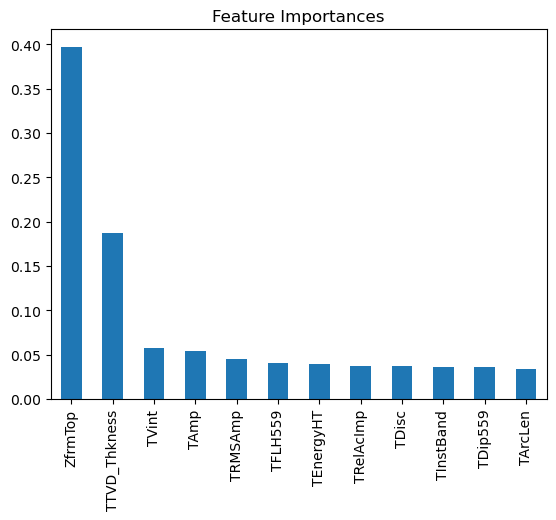

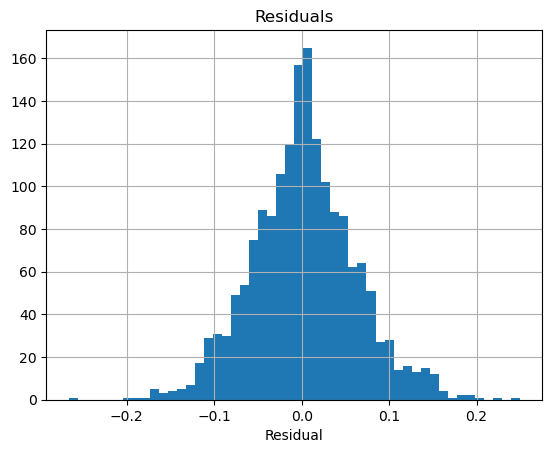

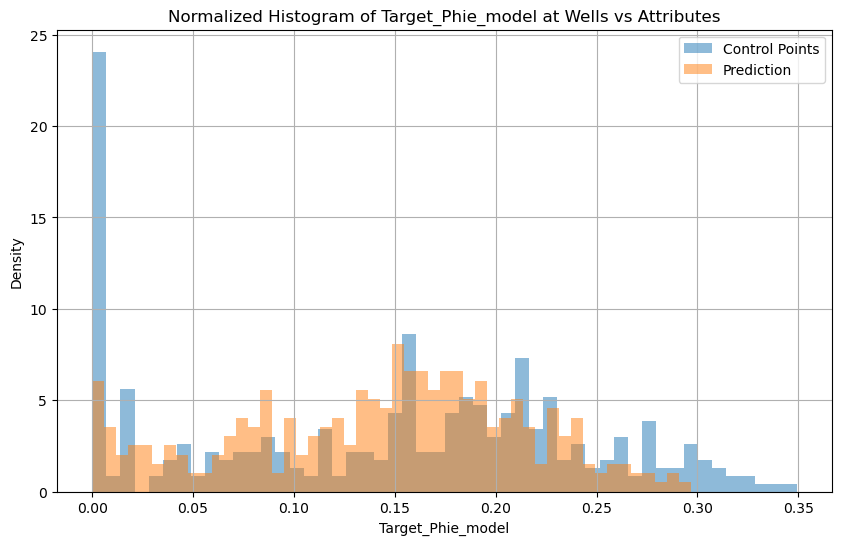

Pearson correlation: 0.607
Spearman correlation: 0.592
Kendall correlation: 0.426
Standard Deviation of the difference: 0.079


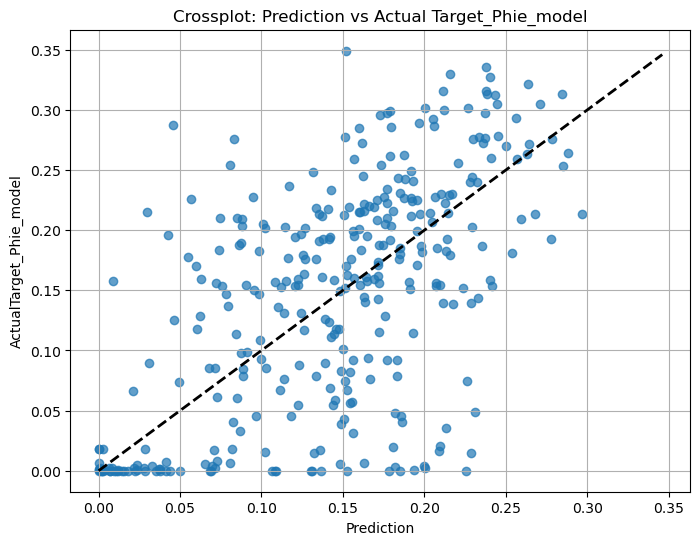

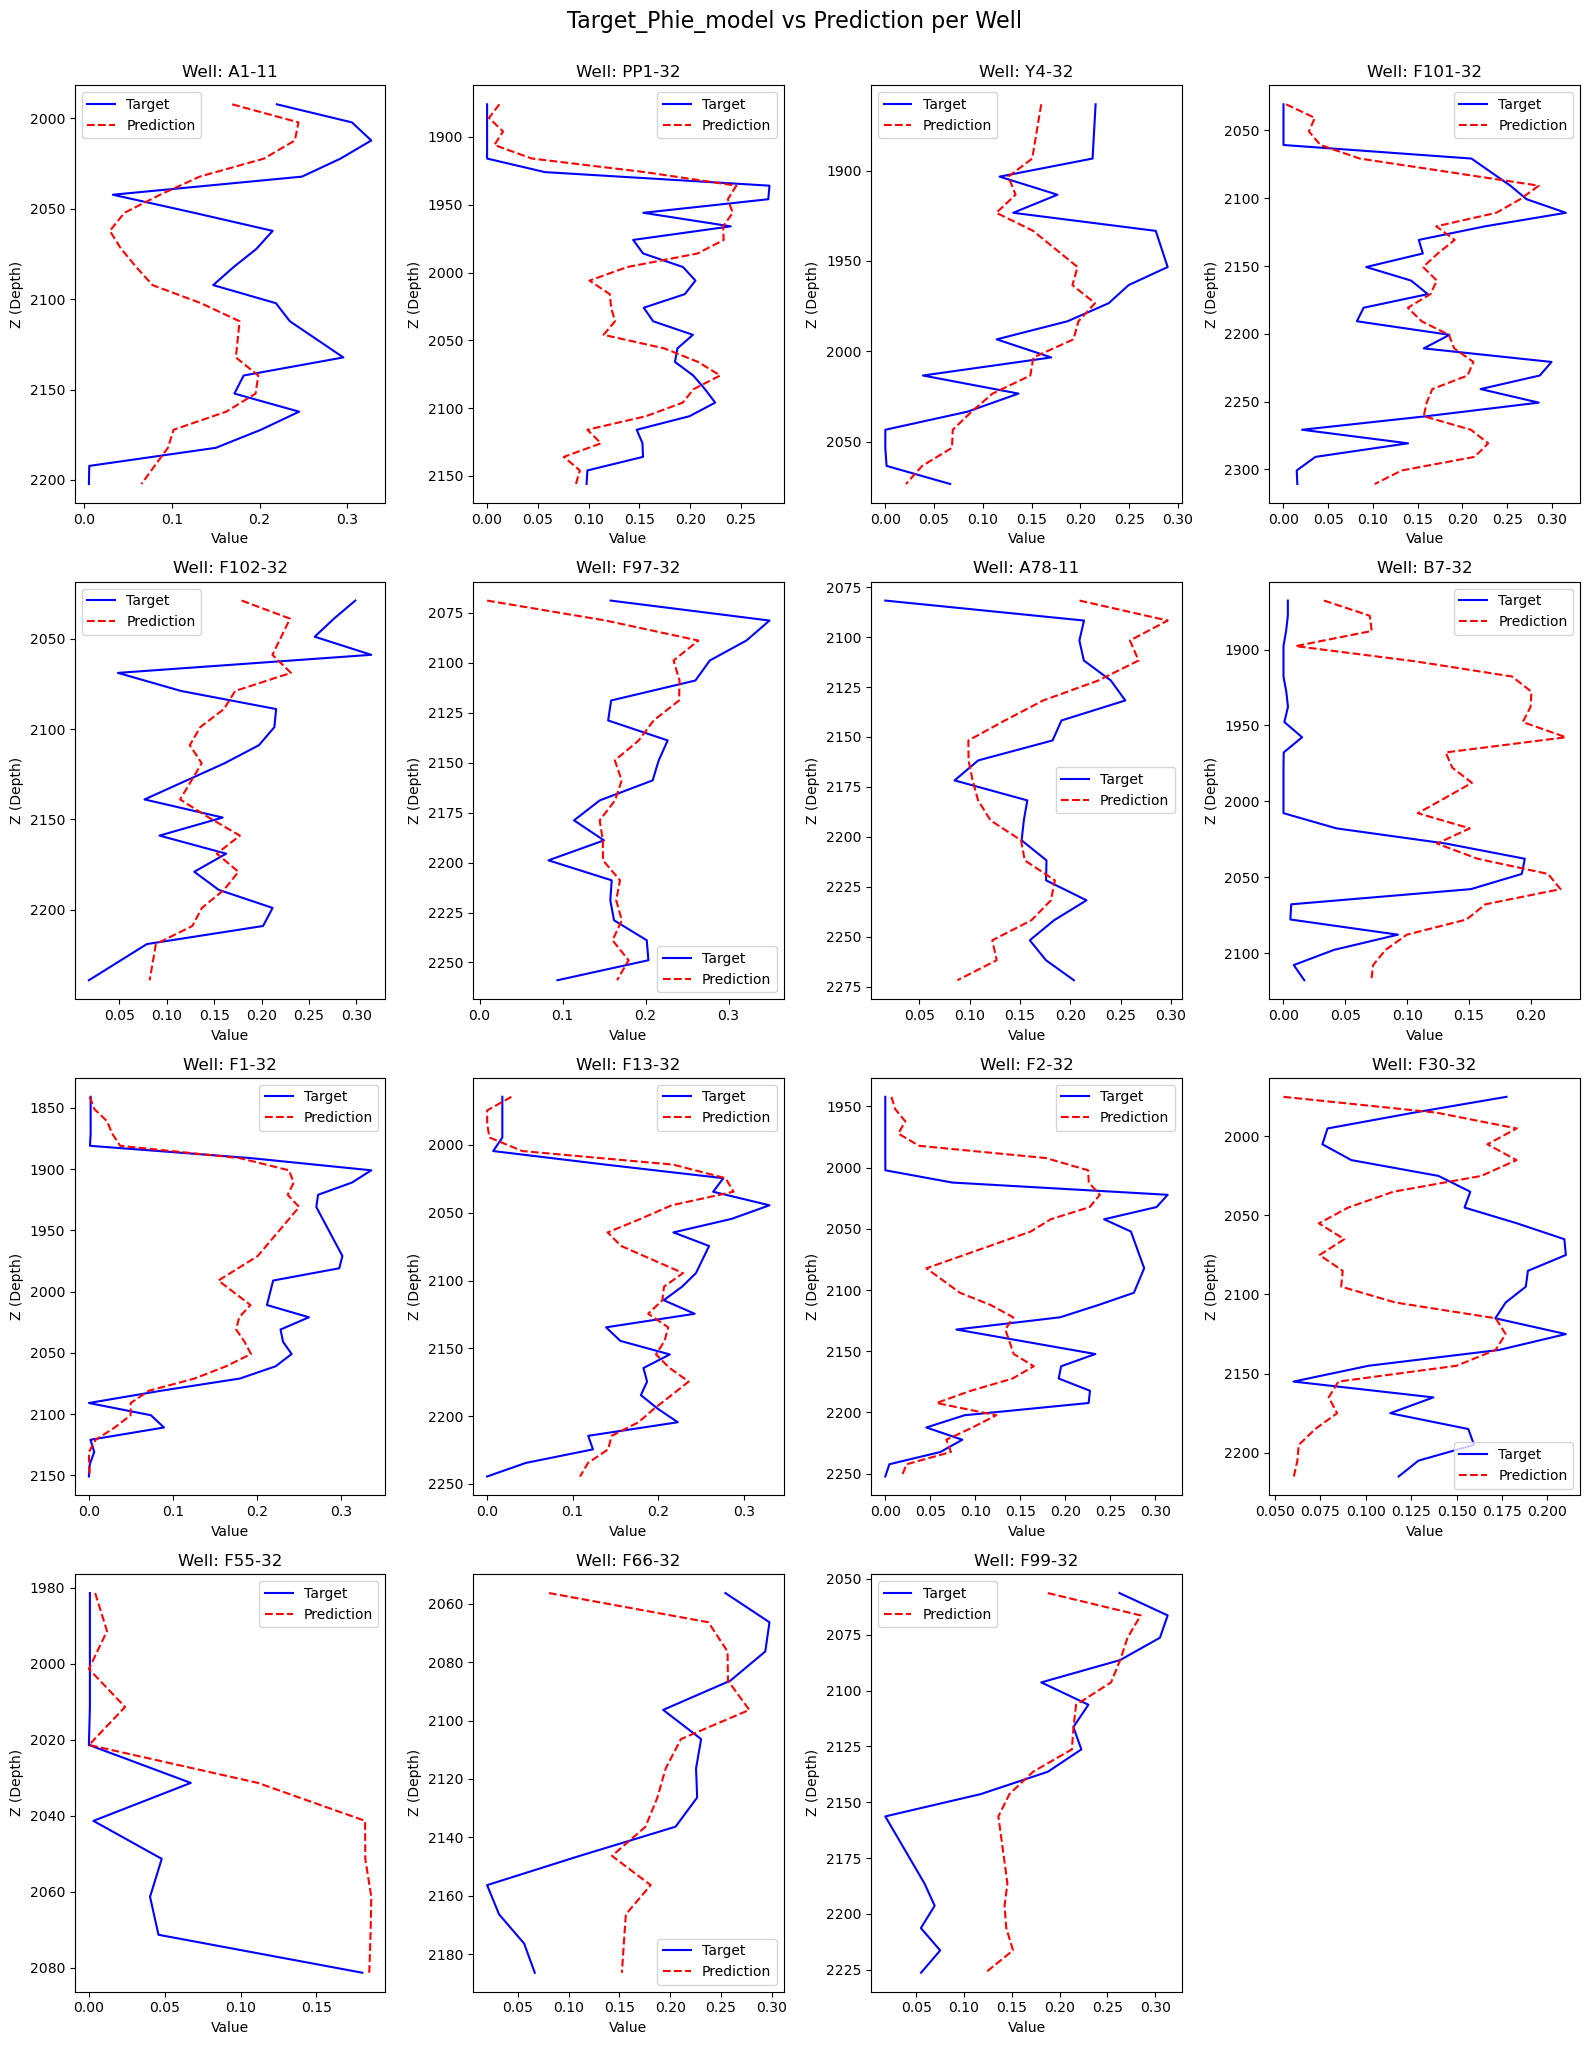

In [17]:
'''
BLIND WELL TESTING
'''

df_all=df_test.copy()

import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler ,StandardScaler
  
target= 'Target_Phie_model'    
target_columns = ['Target_Phie_model'] # [col for col in df_filtered.columns if col.startswith('Target_')]
#included 'ZfrmTop''TTVD_Thkness',,, 'TVint','TRMSAmp', 'TRelAcImp','ZfrmTop, 'TTFLH559', 'TReflStr',
# remove_features= ['X','Y','Z','HFU','TAmp', 'TDip559', 'TEnergyHT', 'TDisc', 'TPosCurv559' 'TQfctr', 'TReflStr', 'TArcLen', 'TTFLH559','TInstBand',  'TTFLH21', 'TInstFreq']#', 'TFLH21', ']   
# input_columns = [col for col in df_filtered.columns if not (col.startswith('WELL_ID') or col.startswith('Target_') or col in remove_features )]


input_columns0 = ['TRelAcImp','TVint','TInstBand','TTFLH559','TDisc','TArcLen','TQfctr','TFLH559','TEnergyHT','TNegCurv559','TSweet','TReflStr','TFLH21','TInstFreq','TPosCurv559','TTFLH21','TRMSAmp','TAmp']
input_columns0_1 = ['ZfrmTop','TRelAcImp','TVint','TInstBand','TTFLH559','TDisc','TArcLen','TQfctr','TFLH559','TEnergyHT','TNegCurv559','TSweet','TReflStr','TFLH21','TInstFreq','TPosCurv559','TTFLH21','TRMSAmp','TAmp']
input_columns0_2 = ['TAmp', 'TArcLen', 'TFLH21', 'TVint', 'ZfrmTop', 'TFLH559']
input_columns1 = ['ZfrmTop','TVint','TQfctr','TFLH21','TRelAcImp','TFLH559','TSweet','TRMSAmp','TAmp','TDisc','TNegCurv559','TTFLH559','TEnergyHT','TDip559','TReflStr','TArcLen','TInstBand','TInstFreq','TTFLH21','TPosCurv559']
input_columns2 = ['ZfrmTop','TTVD_Thkness','TAmp','TVint','TRelAcImp','TSweet','TTFLH21','TNegCurv21','TQfctr','TNegCurv559','TEnergyHT','TPosCurv21','TPosCurv559','TInstBand','TDisc','TRMSAmp','TArcLen','TFLH21','TInstFreq','TDip559','TReflStr','TTFLH559','TFLH559']
input_columns3 = ['TRelAcImp','TVint','TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH559', 'TInstBand', 'TRMSAmp', 'ZfrmTop','TTVD_Thkness']

input_columns = input_columns3

X = df_filtered[input_columns]
y = df_filtered[target]

# Now split the data into training and test sets using the encoded labels
X_train_, X_test_, y_train_, y_test_ = train_test_split(X,  y, test_size=0.3 ,random_state=42  ) #,random_state=30 )
X_train, X_test, y_train, y_test = X_train_.copy(), X_test_.copy(), y_train_.copy(), y_test_.copy()

#X_train.drop(columns=['Y','X'],inplace=True) #'Y','X', 'WellID','WELL_ID'
#X_test.drop(columns=['Y','X'],inplace=True) #'Y','X','WellID','WELL_ID'

#scaler = MinMaxScaler()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=input_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=input_columns)

# Initialize and train the XGBoost model
model = xgb.XGBRegressor(max_depth = 4, objective='reg:squarederror')
model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = model.predict(X_test_scaled)
if target =='Target_HFU_Discrete':
    y_pred = np.round(y_pred,decimals=0)
    #y_pred = np.floor(y_pred)
    #y_pred = np.ceil(y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.2f}")

# Feature importances
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index=X_train_scaled.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

print("Features sorted by their importance:")
print(feature_importances)

# Plot feature importances
feature_importances.plot(kind='bar', legend=False, title='Feature Importances')
plt.show()

# Plot predictions against actual
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

# Plot residuals histogram
residuals = y_pred - y_test
residuals.hist(bins=50)
plt.title('Residuals')
plt.xlabel('Residual')
plt.show()

# Return the necessary metrics and model details
#print ('r2',r2,'model', model,'feature_importances', feature_importances)
#---------------------------------------------

df_features_aligned = df_all[input_columns]
input_scaled = scaler.transform(df_features_aligned)

df_output = pd.DataFrame(input_scaled, columns=input_columns)

y_final = model.predict(df_output)

#min_value = df_raw[target].min() #0.04
#max_value = df_raw[target].max() #0.28
# Clip the values in the 'predictions' array
#predictions = np.clip(y_pred, a_min=min_value, a_max=max_value)

df_output['X']=df_all['X'];
df_output['Y']=df_all['Y'];
df_output['Z']=df_all['Z'];
df_output[target]=df_test[target];
df_output['WELL_ID']=df_test['WELL_ID'];
df_output['Prediction']=y_final;
#df_output[['Target_Phie_model']]=df_output[['Target_Phie_model']].clip(lower=0)
df_output['Prediction'] = np.where(df_output['Prediction'] <= 0, 0.0001, df_output['Prediction'])

df_output.to_csv('Test_wells_output_Phie_Demo.csv',sep=',', na_rep='-999.25', float_format=None, columns=['X','Y','Z',target,'Prediction'], header=True, index=False, index_label=None, mode='w'  )
#---------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

# Optional: round coordinates if needed due to floating point precision



plt.figure(figsize=(10, 6))
#plt.hist(df_compare['Target_Phie_model_small'], bins=50, alpha=0.5, label='Target_Phie_model_small')
#plt.hist(df_compare['Target_Phie_model_large'], bins=50, alpha=0.5, label='Target_Phie_model_large')

plt.hist(df_output[target], bins=50, alpha=0.5, label='Control Points', density=True)
plt.hist(df_output['Prediction'], bins=50, alpha=0.5, label='Prediction', density=True)
#plt.hist(df_compare['Z_small'], bins=50, alpha=0.5, label='Z_small', density=True)
#plt.hist(df_compare['Z_large'], bins=50, alpha=0.5, label='Z_large', density=True)

plt.title(f'Normalized Histogram of {target} at Wells vs Attributes')
plt.xlabel(target)
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()




correlation = df_output['Prediction'].corr(df_output[target])
print(f"Pearson correlation: {correlation:.3f}")

# Spearman (rank-based)
spearman_corr =  df_output['Prediction'].corr(df_output[target], method='spearman')
print(f"Spearman correlation: {spearman_corr:.3f}")

# Kendall (ordinal)
kendall_corr =  df_output['Prediction'].corr(df_output[target], method='kendall')
print(f"Kendall correlation: {kendall_corr:.3f}")


# Calculate the difference
df_output['diff'] = df_output['Prediction'] - df_output[target]

# Calculate the standard deviation
std_diff = df_output['diff'].std()
print(f"Standard Deviation of the difference: {std_diff:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(df_output['Prediction'], df_output[target], alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Prediction')
plt.ylabel(f'Actual{target}')
plt.title(f'Crossplot: Prediction vs Actual {target}')
plt.grid(True)
plt.show()







import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df_output['diff'], bins=30, kde=True, color='skyblue')
plt.axvline(0, color='black', linestyle='--', label='Zero Difference')
plt.axvline(std_diff, color='red', linestyle='--', label=f'+1 STD ({std_diff:.2f})')
plt.axvline(-std_diff, color='red', linestyle='--', label=f'-1 STD ({-std_diff:.2f})')
plt.title(f'Distribution of Prediction Errors (Prediction - {target})')
plt.xlabel('Difference')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

# List of unique wells
unique_wells = df_output['WELL_ID'].unique()

# Number of wells
n_wells = len(unique_wells)

# Set up subplots (adjust as needed for many wells)
n_cols = 4
n_rows = (n_wells + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 5), sharey=False)

# Flatten axes for easy indexing
axes = axes.flatten()

for i, well in enumerate(unique_wells):
    ax = axes[i]
    df_well = df_output[df_output['WELL_ID'] == well].sort_values('Z')
    
    ax.plot(df_well[target], df_well['Z'], label='Target', color='blue')
    ax.plot(df_well['Prediction'], df_well['Z'], label='Prediction', color='red', linestyle='--')
    
    ax.set_title(f"Well: {well}")
    ax.set_xlabel('Value')
    ax.set_ylabel('Z (Depth)')
    ax.invert_yaxis()  # Depth increases downward
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(f'{target} vs Prediction per Well', y=1.02, fontsize=16)
plt.show()


Evaluating feature combinations: 100%|█████████████████████████████████████████████| 1000/1000 [01:36<00:00, 10.41it/s]


Best Test R² combination:
['TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH21', 'TTVD_Thkness', 'TVint', 'ZfrmTop']
Test R²: 0.651, Val R²: 0.257

Best Validation R² combination:
['TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH559', 'TInstBand', 'TRMSAmp', 'ZfrmTop']
Val R²: 0.402, Test R²: 0.546
                                              features   test_r2  \
679  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.651152   
118  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.638194   
952  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.633085   
458  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.632555   
392  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.632324   
622  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.629220   
393  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.629752   
677  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.627118   
594  [TAmp, TArcLen, TDip559, TDisc, TEnergyHT, TFL...  0.627456   
874

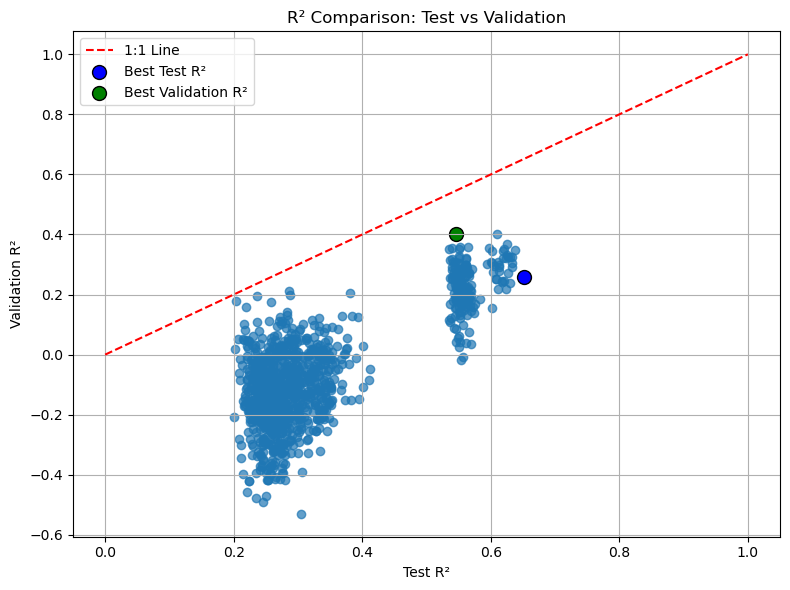


🔵 Best Test R² Combination:
Features: ['TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH21', 'TTVD_Thkness', 'TVint', 'ZfrmTop']
Test R²: 0.651 | Validation R²: 0.257

🟢 Best Validation R² Combination:
Features: ['TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH559', 'TInstBand', 'TRMSAmp', 'ZfrmTop']
Validation R²: 0.402 | Test R²: 0.546


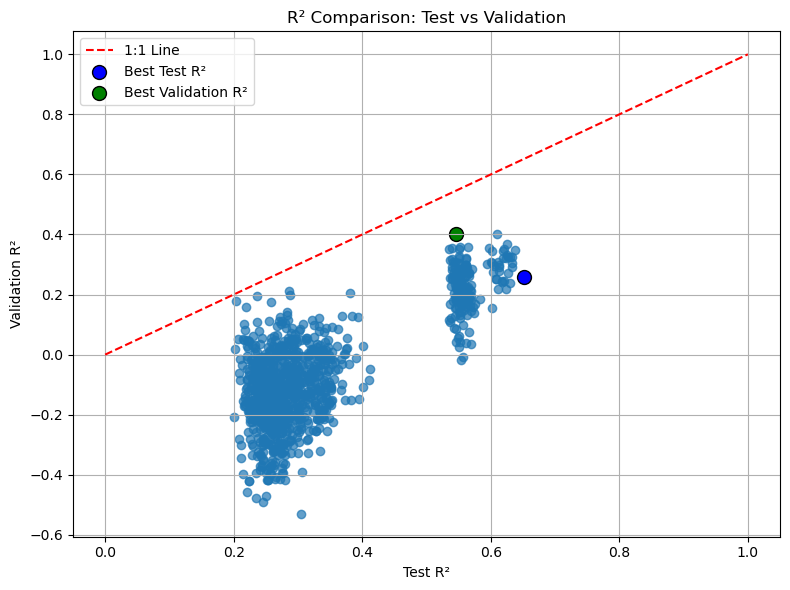

Unique features in successful combinations:
['TAmp', 'TArcLen', 'TDip559', 'TDisc', 'TEnergyHT', 'TFLH21', 'TFLH559', 'TInstBand', 'TInstFreq', 'TNegCurv21', 'TNegCurv559', 'TPosCurv21', 'TPosCurv559', 'TQfctr', 'TRMSAmp', 'TReflStr', 'TRelAcImp', 'TSweet', 'TTFLH21', 'TTFLH559', 'TTVD_Thkness', 'TVint', 'ZfrmTop']
Feature frequency among successful combinations:
              count
TAmp            292
TDip559         292
TDisc           292
TEnergyHT       292
TArcLen         292
TFLH21          172
ZfrmTop         162
TFLH559         143
TInstFreq        98
TInstBand        62
TRelAcImp        55
TVint            53
TReflStr         50
TTVD_Thkness     50
TNegCurv21       47
TNegCurv559      45
TQfctr           43
TSweet           41
TRMSAmp          38
TTFLH21          31
TPosCurv559      27
TPosCurv21       27
TTFLH559         24


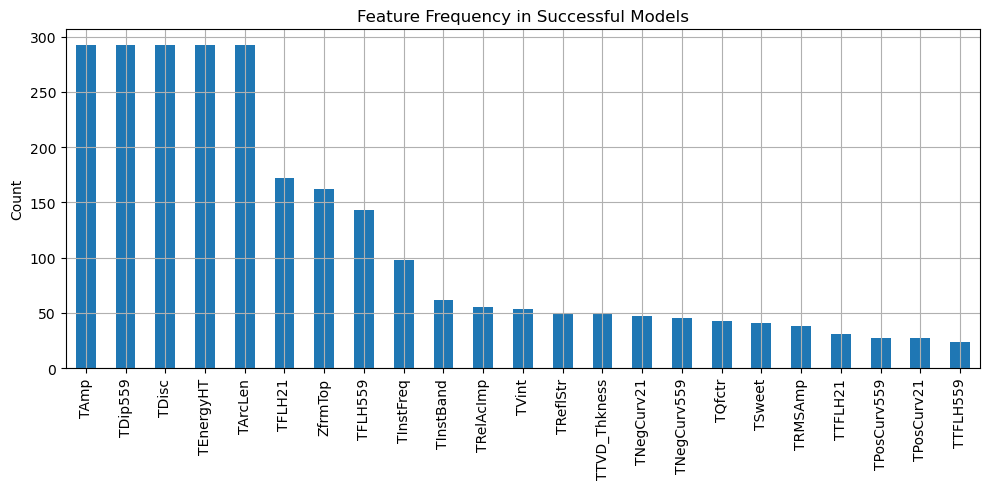

In [14]:
import itertools
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, kendalltau
from tqdm import tqdm
import joblib

def evaluate_feature_combinations(df_filtered, target, df_val,
                                   min_features=5, max_features=10,
                                   excluded_prefixes=('Target_', 'WELL_ID', 'WellID'),
                                   remove_features=('Z','HFU','Y','X'), #,'ZfrmTop' ,'TTVD_Thkness
                                   top_n=100,
                                   save_model_path='best_model_xgb.pkl'):
    """
    Trains/test-splits df_filtered, evaluates model on test set,
    and computes generalization metrics on external validation set.

    Returns a dataframe of both test and validation metrics.
    """
    
    valid_features = [col for col in df_filtered.columns
                      if not col.startswith(excluded_prefixes)
                      and col not in remove_features
                      and col != target]

    results = []
    best_metrics = {'test_pearson': -np.inf}
    best_model_bundle = None

    combos = list(itertools.chain.from_iterable(
        itertools.combinations(valid_features, k) for k in range(min_features, max_features + 1)
    ))

    for combo in tqdm(combos[:top_n], desc="Evaluating feature combinations"):
        try:
            features = list(combo)

            # Split data
            X = df_filtered[features]
            y = df_filtered[target]
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

            # Scale
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # Train
            model = xgb.XGBRegressor(max_depth=4, objective='reg:squarederror', verbosity=0)
            model.fit(X_train_scaled, y_train)

            # Evaluate on test split
            y_pred_test = model.predict(X_test_scaled)
            test_r2 = r2_score(y_test, y_pred_test)
            test_pearson = np.corrcoef(y_test, y_pred_test)[0, 1]
            test_spearman, _ = spearmanr(y_test, y_pred_test)
            test_kendall, _ = kendalltau(y_test, y_pred_test)

            # Evaluate on validation set
            X_val = df_val[features]
            y_val = df_val[target]
            X_val_scaled = scaler.transform(X_val)
            y_pred_val = model.predict(X_val_scaled)

            val_r2 = r2_score(y_val, y_pred_val)
            val_pearson = np.corrcoef(y_val, y_pred_val)[0, 1]
            val_spearman, _ = spearmanr(y_val, y_pred_val)
            val_kendall, _ = kendalltau(y_val, y_pred_val)

            results.append({
                'features': features,
                'test_r2': test_r2,
                'test_pearson': test_pearson,
                'test_spearman': test_spearman,
                'test_kendall': test_kendall,
                'val_r2': val_r2,
                'val_pearson': val_pearson,
                'val_spearman': val_spearman,
                'val_kendall': val_kendall
            })

            # Save best based on test Pearson
            if test_pearson > best_metrics['test_pearson']:
                best_metrics = {
                    'test_r2': test_r2,
                    'test_pearson': test_pearson,
                    'test_spearman': test_spearman,
                    'test_kendall': test_kendall,
                    'val_r2': val_r2,
                    'val_pearson': val_pearson,
                    'val_spearman': val_spearman,
                    'val_kendall': val_kendall
                }
                best_model_bundle = {
                    'model': model,
                    'scaler': scaler,
                    'features': features,
                    'metrics': best_metrics
                }

        except Exception:
            continue

    if best_model_bundle:
        joblib.dump(best_model_bundle, save_model_path)

    df_results = pd.DataFrame(results)
    if not df_results.empty:
        df_results.sort_values(by='test_pearson', ascending=False, inplace=True)
    return df_results


import matplotlib.pyplot as plt

def plot_r2_comparison(df_results):
    plt.figure(figsize=(8, 6))
    plt.scatter(df_results['test_r2'], df_results['val_r2'], alpha=0.7)
    plt.plot([0, 1], [0, 1], '--r', label='1:1 Line')
    plt.xlabel('Test R²')
    plt.ylabel('Validation R²')
    plt.title('R² Comparison: Test vs Validation')
    plt.grid(True)
    plt.legend()

    # Highlight the best model in both dimensions
    best_test_idx = df_results['test_r2'].idxmax()
    best_val_idx = df_results['val_r2'].idxmax()

    plt.scatter(df_results.loc[best_test_idx, 'test_r2'],
                df_results.loc[best_test_idx, 'val_r2'],
                color='blue', label='Best Test R²', s=100, edgecolor='k')

    plt.scatter(df_results.loc[best_val_idx, 'test_r2'],
                df_results.loc[best_val_idx, 'val_r2'],
                color='green', label='Best Validation R²', s=100, edgecolor='k')

    plt.legend()
    plt.tight_layout()
    plt.show()








import matplotlib.pyplot as plt

def analyze_and_plot_r2(df_results):
    # Identify best rows
    best_test_idx = df_results['test_r2'].idxmax()
    best_val_idx = df_results['val_r2'].idxmax()
    
    best_test_row = df_results.loc[best_test_idx]
    best_val_row = df_results.loc[best_val_idx]

    # Print best combinations
    print("\n🔵 Best Test R² Combination:")
    print(f"Features: {best_test_row['features']}")
    print(f"Test R²: {best_test_row['test_r2']:.3f} | Validation R²: {best_test_row['val_r2']:.3f}")

    print("\n🟢 Best Validation R² Combination:")
    print(f"Features: {best_val_row['features']}")
    print(f"Validation R²: {best_val_row['val_r2']:.3f} | Test R²: {best_val_row['test_r2']:.3f}")

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(df_results['test_r2'], df_results['val_r2'], alpha=0.7)
    plt.plot([0, 1], [0, 1], '--r', label='1:1 Line')
    plt.xlabel('Test R²')
    plt.ylabel('Validation R²')
    plt.title('R² Comparison: Test vs Validation')
    plt.grid(True)

    # Highlight best models
    plt.scatter(best_test_row['test_r2'], best_test_row['val_r2'],
                color='blue', s=100, edgecolor='k', label='Best Test R²')
    
    plt.scatter(best_val_row['test_r2'], best_val_row['val_r2'],
                color='green', s=100, edgecolor='k', label='Best Validation R²')

    plt.legend()
    plt.tight_layout()
    plt.show()






# ✅ Run this after evaluate_feature_combinations


target = 'Target_Phie_model'
df_results = evaluate_feature_combinations(
    df_filtered=df_filtered,
    target=target,
    df_val=df_test,
    min_features=9,
    max_features=12,
    top_n=1000,
    save_model_path='best_model_xgb.pkl'
)



# Best on test split
best_test_row = df_results.loc[df_results['test_r2'].idxmax()]
print("Best Test R² combination:")
print(best_test_row['features'])
print(f"Test R²: {best_test_row['test_r2']:.3f}, Val R²: {best_test_row['val_r2']:.3f}")

# Best on validation
best_val_row = df_results.loc[df_results['val_r2'].idxmax()]
print("\nBest Validation R² combination:")
print(best_val_row['features'])
print(f"Val R²: {best_val_row['val_r2']:.3f}, Test R²: {best_val_row['test_r2']:.3f}")


df_results.to_csv("feature_combination_test_val_results.csv", index=False)
print(df_results.head(10))

plot_r2_comparison(df_results)

analyze_and_plot_r2(df_results)

filtered = df_results[(df_results['test_r2'] > 0.2) & (df_results['val_r2'] > 0.0)]
#print(filtered['features'])
# Flatten the list of feature lists and extract unique values
unique_features = sorted(set(f for combo in filtered['features'] for f in combo))
print("Unique features in successful combinations:")
print(unique_features)

from collections import Counter

# Step 1: Flatten all features in the filtered combinations
all_features = [f for combo in filtered['features'] for f in combo]

# Step 2: Count frequency of each feature
feature_counts = Counter(all_features)

# Step 3: Convert to DataFrame for easier viewing/sorting
feature_importance_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['count'])
feature_importance_df.sort_values(by='count', ascending=False, inplace=True)

# Display top features
print("Feature frequency among successful combinations:")
print(feature_importance_df)

# Optional: plot
feature_importance_df.plot(kind='bar', figsize=(10, 5), legend=False, title='Feature Frequency in Successful Models')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()


In [46]:
df_all = pd.read_csv('PL5GrdAttAllData.csv')#, sep=r'\s+',dtype=dtype_dict1)
df_all2 = pd.read_csv('HFUCont_2_output.csv')#, sep=r'\s+',dtype=dtype_dict1)
df_all2.drop(columns=['X','Y','Z'], inplace=True)
df_all2.columns=['HFU']
df_all=pd.concat([df_all,df_all2], axis=1, ignore_index=False)
df_all.reset_index(drop=True, inplace=True)

df_all.head()

,X,Y,Z,TEnergyHT,TDip559,TDisc,TAmp,TArcLen,TFLH21,TFLH559,TInstFreq,TInstBand,TNegCurv21,TReflStr,TPosCurv559,TPosCurv21,TQfctr,TNegCurv559,TRelAcImp,TTFLH21,TTFLH559,TRMSAmp,TSweet,TTVD_Thkness,TVint,ZfrmTop,HFU
0,770075.0,3287825.0,2235.0986,0.910282,1.218768,20.429117,7989.6130,2218.2603,NaN,NaN,32.801826,15.480903,NaN,8246.7140,0.595033,NaN,1.216079,-7.798224,7712.5786,NaN,NaN,5154.0070,1149.5964,267.57788,9722.347,-45.0601,0.056894
1,770125.0,3287825.0,2232.1536,-7.611138,1.541983,22.430027,3990.8203,2145.1309,NaN,NaN,24.593348,19.658737,NaN,5113.3857,NaN,NaN,0.869394,NaN,6721.0166,NaN,NaN,4957.5737,1082.8660,270.07764,9717.980,-45.0080,0.111354
2,770175.0,3287825.0,2229.1973,-25.040937,1.356568,20.398024,1678.0651,2015.4325,NaN,NaN,13.730275,21.326237,NaN,2977.1477,NaN,NaN,0.778491,NaN,5087.3450,NaN,NaN,5065.2124,1037.5449,272.00635,9733.946,-45.1562,0.108934
3,770225.0,3287825.0,2225.8010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,273.35864,9737.562,-45.7796,0.094753
4,770025.0,3287775.0,2236.0020,11.020158,0.791297,13.439408,6744.3380,3056.5352,NaN,0.984454,43.886307,14.094129,NaN,9389.2240,7.588874,NaN,1.599506,-10.189797,6241.9517,NaN,NaN,5419.7964,1042.3150,265.31690,9713.669,-45.0908,0.078529


R²: 0.87
Features sorted by their importance:
              importance
HFU             0.780648
ZfrmTop         0.037307
X               0.028482
Y               0.017443
TVint           0.015238
TRelAcImp       0.015197
TPosCurv559     0.013389
TTVD_Thkness    0.012834
TRMSAmp         0.012212
TSweet          0.010636
TQfctr          0.010273
TFLH21          0.010038
TPosCurv21      0.009875
TNegCurv21      0.009647
TFLH559         0.008607
TNegCurv559     0.008174


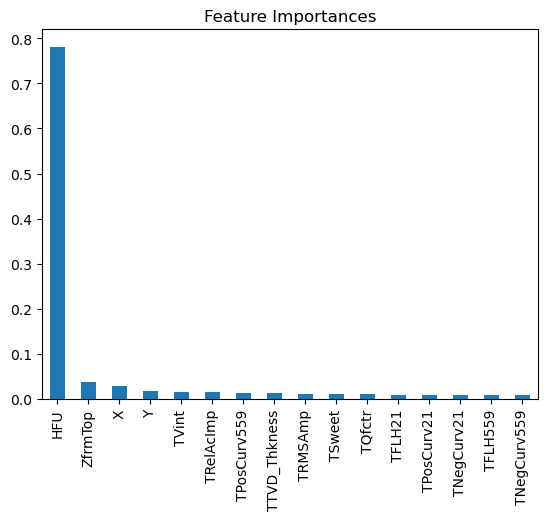

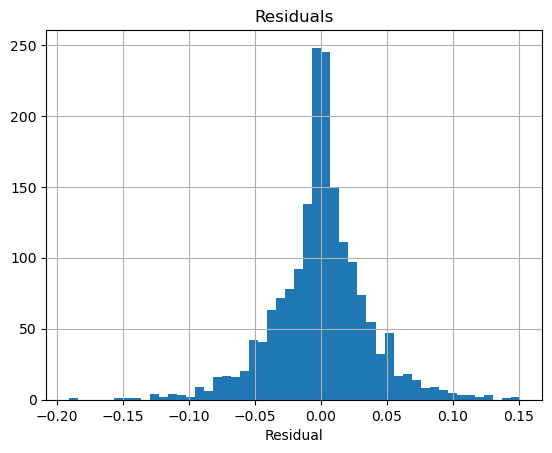

r2 0.8683077119742753 model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) feature_importances               importance
HFU             0.780648
ZfrmTop         0.037307
X               0.028482
Y               0.017443
TVint           0.015238
TRelAcImp       0.015197
TPosCurv559     0.013389
TTVD_

In [47]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler ,StandardScaler
  

target= 'Target_Phie_model'    
target_columns = ['Target_Phie_model'] # [col for col in df_filtered.columns if col.startswith('Target_')]
#included , 'TVint','TRMSAmp', 'TRelAcImp','ZfrmTop, 'TTFLH559', 'TReflStr','ZfrmTop','TTVD_Thkness','X','Y','HFU'
remove_features= ['Z','TAmp', 'TDip559', 'TEnergyHT', 'TDisc', 'TPosCurv559' 'TQfctr', 'TReflStr', 'TArcLen', 'TTFLH559','TInstBand',  'TTFLH21', 'TInstFreq']#', 'TFLH21', ']   
input_columns = [col for col in df_filtered.columns if not (col.startswith('WELL_ID') or col.startswith('Target_') or col in remove_features )]


X = df_filtered[input_columns]
y = df_filtered[target]

# Now split the data into training and test sets using the encoded labels
X_train_, X_test_, y_train_, y_test_ = train_test_split(X,  y, test_size=0.3 ,random_state=42  ) #,random_state=30 )
X_train, X_test, y_train, y_test = X_train_.copy(), X_test_.copy(), y_train_.copy(), y_test_.copy()

#X_train.drop(columns=['Y','X'],inplace=True) #'Y','X', 'WellID','WELL_ID'
#X_test.drop(columns=['Y','X'],inplace=True) #'Y','X','WellID','WELL_ID'

#scaler = MinMaxScaler()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=input_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=input_columns)

# Initialize and train the XGBoost model
model = xgb.XGBRegressor(max_depth = 4, objective='reg:squarederror')
model.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = model.predict(X_test_scaled)
if target =='Target_HFU_Discrete':
    y_pred = np.round(y_pred,decimals=0)
    #y_pred = np.floor(y_pred)
    #y_pred = np.ceil(y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.2f}")

# Feature importances
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index=X_train_scaled.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

print("Features sorted by their importance:")
print(feature_importances)

# Plot feature importances
feature_importances.plot(kind='bar', legend=False, title='Feature Importances')
plt.show()

# Plot predictions against actual
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

# Plot residuals histogram
residuals = y_pred - y_test
residuals.hist(bins=50)
plt.title('Residuals')
plt.xlabel('Residual')
plt.show()

# Return the necessary metrics and model details
print ('r2',r2,'model', model,'feature_importances', feature_importances)
#---------------------------------------------

df_features_aligned = df_all[input_columns]
input_scaled = scaler.transform(df_features_aligned)

df_output = pd.DataFrame(input_scaled, columns=input_columns)

y_final = model.predict(df_output)

#min_value = df_raw[target].min() #0.04
#max_value = df_raw[target].max() #0.28
# Clip the values in the 'predictions' array
#predictions = np.clip(y_pred, a_min=min_value, a_max=max_value)

df_output['X']=df_all['X'];
df_output['Y']=df_all['Y'];
df_output['Z']=df_all['Z'];
df_output['Target_Phie_model']=y_final;
#df_output[['Target_Phie_model']]=df_output[['Target_Phie_model']].clip(lower=0)
df_output['Target_Phie_model'] = np.where(df_output['Target_Phie_model'] < 0, 0, df_output['Target_Phie_model'])

df_output.to_csv('output.csv',sep=',', na_rep='-999.25', float_format=None, columns=['X','Y','Z',target], header=True, index=False, index_label=None, mode='w'  )
#---------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

# Iterate over each feature
# for feature in df_output.columns:
#     plt.figure(figsize=(10, 5))
    
#     # Plot histogram for the training data
#     if feature.startswith("Target_"):
#         sns.histplot(y_test, color='blue', label='Training', kde=True, stat="density", common_norm=False)
#     else:
#         sns.histplot(X_test_scaled[feature], color='blue', label='Training', kde=True, stat="density", common_norm=False)
    
#     # Plot histogram for the ZMAP data
#     try:
#         sns.histplot(df_output[feature], color='orange', label='ZMAP', kde=True, stat="density", common_norm=False)
#     except KeyError:
#         print(feature,' not found')
    
#     plt.title(f'{feature}')
#     plt.legend()
#     plt.show()

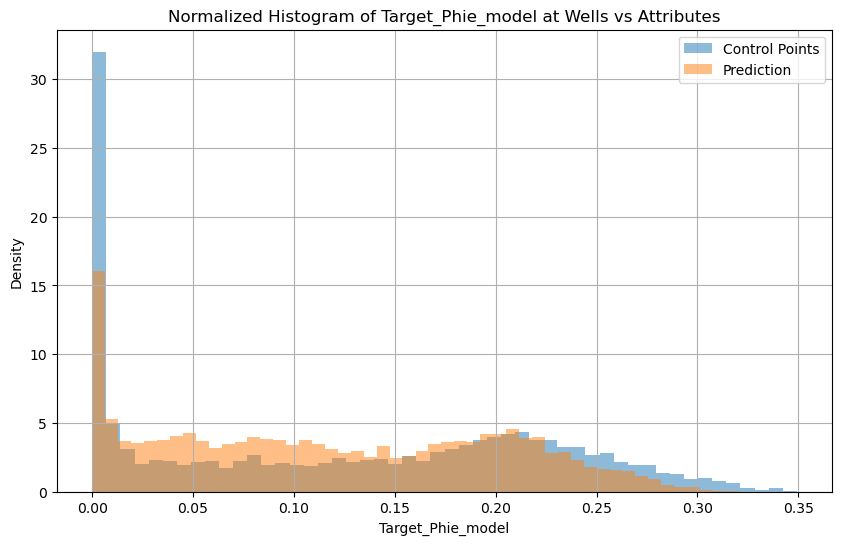

In [48]:
# Optional: round coordinates if needed due to floating point precision
df_small=df_filtered.copy()
df_large=df_output.copy()

df_small['X'] = df_filtered['X'].round(3)
df_small['Y'] = df_filtered['Y'].round(3)
df_large['X'] = df_all['X'].round(3)
df_large['Y'] = df_all['Y'].round(3)

# Perform an inner merge on X and Y
df_compare = pd.merge(
    df_small, df_large,
    on=['X', 'Y'],
    suffixes=('_small', '_large'),
    how='inner'  # only keep matching coordinates
)

#df_compare.loc[:,['X','Y','Z_small','Z_large']]

plt.figure(figsize=(10, 6))

#plt.hist(df_compare['Target_Phie_model_small'], bins=50, alpha=0.5, label='Target_Phie_model_small')
#plt.hist(df_compare['Target_Phie_model_large'], bins=50, alpha=0.5, label='Target_Phie_model_large')

plt.hist(df_compare['Target_Phie_model_small'], bins=50, alpha=0.5, label='Control Points', density=True)
plt.hist(df_compare['Target_Phie_model_large'], bins=50, alpha=0.5, label='Prediction', density=True)
#plt.hist(df_compare['Z_small'], bins=50, alpha=0.5, label='Z_small', density=True)
#plt.hist(df_compare['Z_large'], bins=50, alpha=0.5, label='Z_large', density=True)

plt.title(f'Normalized Histogram of {target} at Wells vs Attributes')
plt.xlabel(target)
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Exports the point set as .CSV

import pandas as pd
from scipy.spatial import cKDTree

well_map = pd.read_csv("Well_ID.csv")  # expected columns: 'WellID', 'WELL_ID'
well_id_map = well_map[['X', 'Y', 'WellID', 'WELL_ID']].drop_duplicates(subset='WellID')
well_id_map.reset_index(drop=True,inplace=True)

df_small=df_filtered.copy()
df_large=df_output.copy()


import pandas as pd
from scipy.spatial import cKDTree

# === STEP 1: Load data ===
# well_id_map = pd.read_csv("Well_ID.csv")
# df_large = pd.read_csv("BLAYER_7AttGrid3_Arith.dat", delim_whitespace=True)

# === STEP 2: Round coordinates ===
well_id_map[['X', 'Y']] = well_id_map[['X', 'Y']].round(6)
df_large[['X', 'Y']] = df_large[['X', 'Y']].round(6)

# === STEP 3: Build KDTree from df_large points ===
tree_large = cKDTree(df_large[['X', 'Y']].values)
well_coords = well_id_map[['X', 'Y']].values

# Find all nearby points in df_large within 100 meters of each well
matches = tree_large.query_ball_point(well_coords, r=100.0)

# === STEP 4: Match wells to nearest grid column (X, Y) and extract series ===
matched_rows = []
for i, point_indices in enumerate(matches):
    if not point_indices:
        continue

    well_info = well_id_map.iloc[i]
    well_x, well_y = well_info['X'], well_info['Y']

    # Get nearby points from df_large
    nearby_points = df_large.iloc[point_indices].copy()

    # Use the most common (X, Y) as the matched grid column
    dominant_location = nearby_points.groupby(['X', 'Y']).size().idxmax()
    matched_column = nearby_points[
        (nearby_points['X'] == dominant_location[0]) &
        (nearby_points['Y'] == dominant_location[1])
    ]

    # Drop duplicated Z values (if any)
    matched_column = matched_column.drop_duplicates(subset='Z')

    # Replace X and Y with exact coordinates from well_id_map
    matched_column['X'] = well_x
    matched_column['Y'] = well_y

    # Add well identifiers
    matched_column['WellID'] = well_info['WellID']
    matched_column['WELL_ID'] = well_info['WELL_ID']

    matched_rows.append(matched_column)

# === STEP 5: Combine and export ===
if matched_rows:
    final_df = pd.concat(matched_rows, ignore_index=True)
    final_df = final_df.sort_values(by=['WellID', 'Z'])

    final_df.to_csv("final_well_series_matched_exact_XY.csv", index=False)
    print("✅ Output saved as 'final_well_series_matched_exact_XY.csv'")
else:
    print("⚠️ No matching points found within 100m for any wells.")




✅ Output saved as 'final_well_series_matched_exact_XY.csv'


In [50]:
df_output.head()
export_df = df_output.copy()
export_df = export_df.loc[:,['X','Y','Z','Target_Phie_model']]
export_df.head()

,X,Y,Z,Target_Phie_model
0,770075.0,3287825.0,2235.0986,0.110255
1,770125.0,3287825.0,2232.1536,0.112774
2,770175.0,3287825.0,2229.1973,0.113077
3,770225.0,3287825.0,2225.8010,0.057898
4,770025.0,3287775.0,2236.0020,0.066987


In [51]:
import os
import numpy as np
from zmapio import ZMAPGrid

import numpy as np

def zmap_to_numpy_array(filename):
    count = 0
    hdr=[]
    name=''
    with open(filename) as h:
        for line in h:
            if line.startswith('!'): 
                count += 1
            if line.startswith('@') and not line.startswith('@\n'):
                name = line.split('@')[1].split(',')[0]
                count += 1
                hdr.append(next(h)); count += 1
                hdr.append(next(h)); count += 1
                count += 1

    hdr = [x.strip('\n') for x in ','.join(hdr).split(',')]
    if hdr[1] ==' ': null=np.nan
    else: null = float(hdr[1])

    xmin, xmax, ymin, ymax = [ float(x) for x in hdr[7:11]]
    grid_rows, grid_cols = [int(y) for y in hdr[5:7]]
    binx=(xmax-xmin)/(grid_cols-1)
    biny=(ymax-ymin)/(grid_rows-1)
    # Close the file
    h.close()

    with open(filename) as f:
        [next(f) for _ in range(count)]                
        for line in f:
            grid = (np.asarray([word for line in f for word in line.split()]).astype(float)).reshape(grid_cols, grid_rows).T
    grid[grid==null]=np.nan

        # Build X and Y grids
    x = np.linspace(  xmin,xmax,grid_cols)
    y = np.linspace(ymax,ymin,  grid_rows)

    # Close the file
    f.close()
    print(name,'\n',null, xmin, xmax, ymin, ymax, grid_rows, grid_cols,binx,biny,grid.shape)
    return grid,x,y


import pandas as pd

def process_zmap_files_in_directory(directory_path):
    """
    Processes all ZMAP grid files in the specified directory and converts them to a DataFrame.

    Parameters:
    - directory_path (str): Path to the directory containing ZMAP grid files.

    Returns:
    - pd.DataFrame: DataFrame where each column is a flattened NumPy array from a ZMAP file.
    """
    feature_data = {}
    for filename in os.listdir(directory_path):
        if filename.lower().endswith('.dat'):  # Adjust the extension as needed
            filepath = os.path.join(directory_path, filename)
            array_name = os.path.splitext(filename)[0]
            zmap_array = zmap_to_numpy_array(filepath)  #+300
            # Flatten the 2D array to 1D
            feature_data[array_name] = zmap_array.flatten()
    # Create DataFrame from the dictionary
    df_features = pd.DataFrame(feature_data)
    return df_features

def working_with_zmap_grid_full(filename):
    count = 0
    hdr=[]
    with open(filename) as h:
        for line in h:
            if line.startswith('!'): 
                count += 1
            if line.startswith('@') and not line.startswith('@\n'):
                count += 1
                hdr.append(next(h)); count += 1
                hdr.append(next(h)); count += 1
                count += 1

    hdr = [x.strip('\n') for x in ','.join(hdr).split(',')]
    if hdr[1] ==' ': null=np.nan
    else: null = float(hdr[1])

    xmin, xmax, ymin, ymax = [ float(x) for x in hdr[7:11]]
    grid_rows, grid_cols = [int(y) for y in hdr[5:7]]
    binx=(xmax-xmin)/(grid_cols-1)
    biny=(ymax-ymin)/(grid_rows-1)
    # Close the file
    h.close()

    with open(filename) as f:
        [next(f) for _ in range(count)]                
        for line in f:
            grid = (np.asarray([word for line in f for word in line.split()]).astype(float)).reshape(grid_cols, grid_rows).T
    grid[grid==null]=np.nan

    # Close the file
    f.close()
    print(null, xmin, xmax, ymin, ymax, grid_rows, grid_cols,binx,biny,grid.shape)
    return null, xmin, xmax, ymin, ymax, grid_rows, grid_cols,binx,biny,grid

T_BLAYER_7_top 
 1e+30 739750.0 753450.0 3289775.0 3305450.0 628 549 25.0 25.0 (628, 549)


TTopPL5_10ft 
 1e+30 754200.0 810250.0 3240050.0 3287950.0 959 1122 50.0 50.0 (959, 1122)


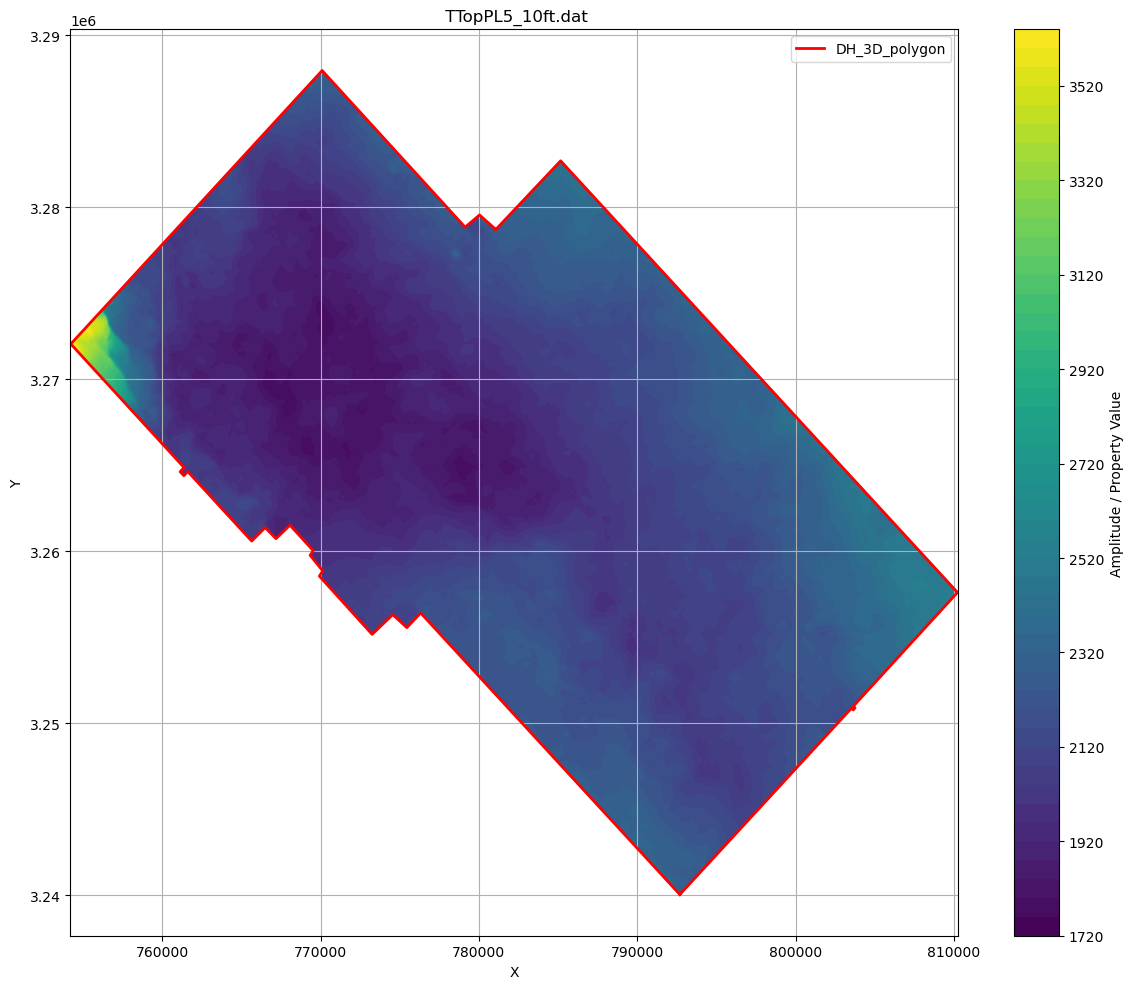

TBottomPL5 
 1e+30 754200.0 810250.0 3240050.0 3287950.0 959 1122 50.0 50.0 (959, 1122)


In [52]:
import numpy as np
import matplotlib.pyplot as plt

bahi_polygon = pd.read_csv("FIELD_3D_poly.txt", sep=r'\s+')

for grids in ['TTopPL5_10ft.dat','TBottomPL5.dat']:
    grid, x, y = zmap_to_numpy_array(grids)
    
    X, Y = np.meshgrid(x, y)
    
    plt.figure(figsize=(12, 10))
    contour = plt.contourf(X, Y, grid, levels=50, cmap='viridis')
    
    # Add polygon
    plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-', linewidth=2, label='FIELD_3D_polygon')
    
    #plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    
    plt.colorbar(contour, label="Amplitude / Property Value")
    plt.title(f" {grids}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.gca().invert_yaxis()  # optional
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [53]:
# === Full Cell ===

import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# === Load Top and Bottom ZMAP grids ===
toparray_grid, toparray_x, toparray_y = zmap_to_numpy_array('TTopPL5_10ft.dat')
bottomarray_grid, bottomarray_x, bottomarray_y = zmap_to_numpy_array('TBottomPL5.dat')

# === Load your scattered pointset ===
# df_large = pd.read_csv("your_data.csv")  # If reading from file
df_large = export_df.copy()  # If already loaded in memory

# === Define grid resolution ===
dx = 50  # X grid spacing
dy = 50  # Y grid spacing
dz = 10   # Z grid spacing

# === Define regular grid ranges ===
x_min, x_max = df_large['X'].min(), df_large['X'].max()
y_min, y_max = df_large['Y'].min(), df_large['Y'].max()
z_min, z_max = df_large['Z'].min(), df_large['Z'].max()

x_grid = np.arange(x_min, x_max + dx, dx)
y_grid = np.arange(y_min, y_max + dy, dy)
z_grid = np.arange(z_min, z_max + dz, dz)

# === Create empty 3D volume ===
volume = np.full((len(x_grid), len(y_grid), len(z_grid)), np.nan, dtype=np.float32)

# === Create 2D meshgrid for working X, Y ===
Xg, Yg = np.meshgrid(x_grid, y_grid, indexing='ij')

# === Prepare Top and Bottom surfaces for interpolation ===
X_top, Y_top = np.meshgrid(toparray_x, toparray_y)  # Correctly match shape (rows, cols)

# === Interpolate Top and Bottom to working Xg, Yg ===
top_interp = griddata((X_top.flatten(), Y_top.flatten()), toparray_grid.flatten(), (Xg, Yg), method='linear')
bottom_interp = griddata((X_top.flatten(), Y_top.flatten()), bottomarray_grid.flatten(), (Xg, Yg), method='linear')

# === Fill the volume slice by slice ===
for i, z in enumerate(z_grid):
    # Filter input points near this Z level
    z_slice = df_large[np.abs(df_large['Z'] - z) <= dz/2]

    if z_slice.empty or len(z_slice) < 4:
        continue  # Skip if empty or too few points

    points = z_slice[['X', 'Y']].values
    values = z_slice['Target_Phie_model'].values  # <<< Change if you want other attribute

    # Interpolate scattered points to regular grid
    grid2d = griddata(points, values, (Xg, Yg), method='linear', fill_value=np.nan)

    # Apply Top/Bottom horizon mask
    mask_outside = (z < top_interp) | (z > bottom_interp)
    grid2d[mask_outside] = np.nan

    # Insert into 3D volume
    volume[:, :, i] = grid2d

# === Save the 3D volume ===
np.savez("volume_cube_clipped.npz", volume=volume, x=x_grid, y=y_grid, z=z_grid)
print("✅ Saved filtered volume to 'volume_cube_clipped.npz'")

# === Print info ===
print(f"Cube shape: {volume.shape}")
print(f"X range: {x_min:.1f} to {x_max:.1f}, steps: {len(x_grid)}")
print(f"Y range: {y_min:.1f} to {y_max:.1f}, steps: {len(y_grid)}")
print(f"Z range: {z_min:.1f} to {z_max:.1f}, steps: {len(z_grid)}")


TTopPL5_10ft 
 1e+30 754200.0 810250.0 3240050.0 3287950.0 959 1122 50.0 50.0 (959, 1122)
TBottomPL5 
 1e+30 754200.0 810250.0 3240050.0 3287950.0 959 1122 50.0 50.0 (959, 1122)
✅ Saved filtered volume to 'volume_cube_clipped.npz'
Cube shape: (1117, 954, 231)
X range: 754325.0 to 810125.0, steps: 1117
Y range: 3240175.0 to 3287825.0, steps: 954
Z range: 1724.2 to 4020.4, steps: 231


In [54]:
# === Cross Section QC Cell ===

import numpy as np
import matplotlib.pyplot as plt

# === Load the saved volume ===
data = np.load('volume_cube_clipped.npz')
volume = data['volume']
x = data['x']
y = data['y']
z = data['z']

print(f"Volume shape: {volume.shape}")  # (len(x), len(y), len(z))

# === Select a cross-section ===
# You can pick either:
# - A fixed Y index to plot X-Z section (vertical slice along Y)
# - A fixed X index to plot Y-Z section

# Example: Cross section at middle Y
iy = len(y) // 2  # Middle Y index

# Extract cross-section (X vs Z)
cross_section = volume[:, iy, :]  # Shape: (X, Z)

# === Plot cross section ===
plt.figure(figsize=(14, 8))
plt.imshow(
    cross_section.T,
    extent=[x.min(), x.max(), z.max(), z.min()],  # Flip Z axis (depth increasing downward)
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='Attribute Value')
plt.title(f"Cross Section at Y index {iy} (Y ≈ {y[iy]:.1f})")
plt.xlabel('X Coordinate')
plt.ylabel('Z (Depth)')
#plt.gca().invert_yaxis()  # Depth increases down
plt.grid(True)
plt.tight_layout()
plt.show()


Volume shape: (1117, 954, 231)


Volume shape: (1117, 954, 231)  (X: 1117, Y: 954, Z: 231)
Z range: 1724.2 ft to 4024.2 ft  |  Step: [10.]
Min non-NaN value: -0.000
Max value: 0.351


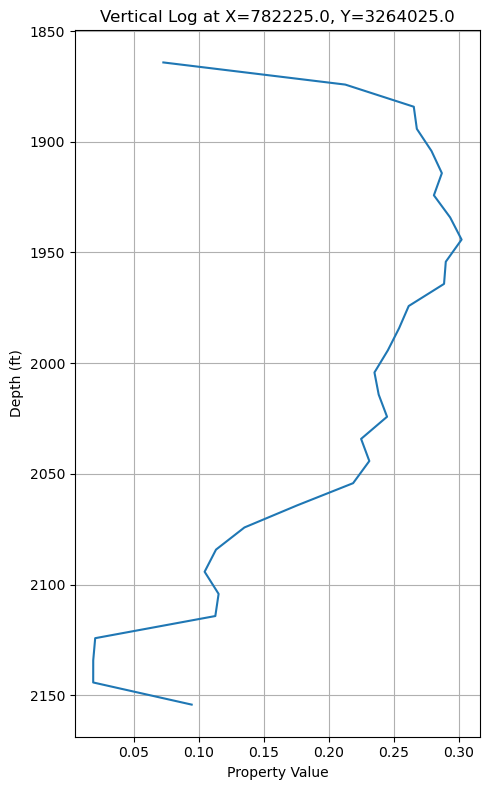

In [55]:
# Vertical and areal QC of .npz file

import numpy as np
import matplotlib.pyplot as plt

# === Load the cube ===
data = np.load("volume_cube_clipped.npz")
volume = data['volume']
x_grid = data['x']
y_grid = data['y']
z_grid = data['z']

# === Summary (already in your code) ===
print(f"Volume shape: {volume.shape}  (X: {len(x_grid)}, Y: {len(y_grid)}, Z: {len(z_grid)})")
print(f"Z range: {z_grid.min():.1f} ft to {z_grid.max():.1f} ft  |  Step: {np.unique(np.diff(z_grid))}")
print(f"Min non-NaN value: {np.nanmin(volume):.3f}")
print(f"Max value: {np.nanmax(volume):.3f}")

# === Vertical Log through Center ===
ix = len(x_grid) // 2
iy = len(y_grid) // 2
property_log = volume[ix, iy, :]

plt.figure(figsize=(5, 8))
plt.plot(property_log, z_grid)
plt.gca().invert_yaxis()
plt.title(f"Vertical Log at X={x_grid[ix]:.1f}, Y={y_grid[iy]:.1f}")
plt.xlabel("Property Value")
plt.ylabel("Depth (ft)")
plt.grid()
plt.tight_layout()
plt.show()

# === 1. Lateral Map at Middle Z Slice ===
iz = len(z_grid) // 3  # pick a representative depth level
z_value = z_grid[iz]
z_slice = volume[:, :, iz]

plt.figure(figsize=(8, 6))
plt.imshow(z_slice.T, origin='lower', cmap='viridis',
           extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()],
           aspect='auto')
plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-o', label='ZONE_A OWC Polygon')
plt.colorbar(label='Property Value')
plt.title(f"Lateral Map at Depth Z = {z_value:.1f} ft")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Footprint Map: count of non-NaN values per (X, Y) ===
valid_counts = np.sum(~np.isnan(volume), axis=2)

plt.figure(figsize=(8, 6))
plt.imshow(valid_counts.T, origin='lower', cmap='plasma',
           extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()],
           aspect='auto')
plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-o', label='ZONE_A OWC Polygon')
plt.colorbar(label='Valid Depth Samples')
plt.title("Data Footprint Map (X-Y Coverage)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.tight_layout()
plt.show()


<LOCAL_PATH>:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
<LOCAL_PATH>:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


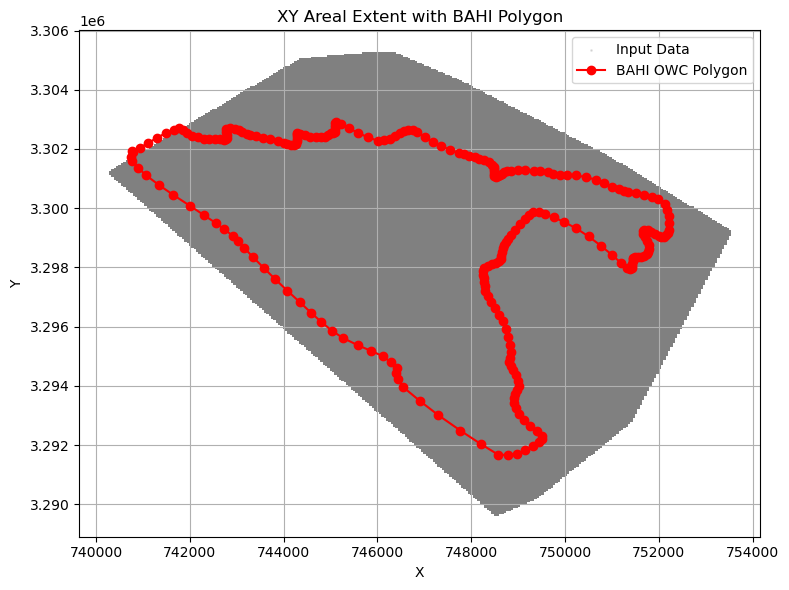

In [180]:

# Areal QC of a dataframe

import pandas as pd
import matplotlib.pyplot as plt




# === Step 3: Overlay it on your data's XY footprint (if df_large is loaded) ===
if 'df_large' in globals():
    plt.figure(figsize=(8, 6))
    plt.scatter(df_large['X'], df_large['Y'], s=1, alpha=0.2, label='Input Data', color='gray')
    plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-o', label='ZONE_A OWC Polygon')
    plt.title("XY Areal Extent with ZONE_A Polygon")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ df_large not found. Load your data first to see the overlay.")


In [56]:
# Convert .npz 3D array to Segy file

import numpy as np
import segyio
from scipy.interpolate import interp1d

# === Load your saved volume ===
#data = np.load("volume_cube.npz")
data = np.load("volume_cube_clipped.npz")
volume = data['volume']       # shape: (X, Y, Z)
x_grid = data['x']
y_grid = data['y']
z_grid = data['z']            # original depth values, e.g., 2500–3200 ft

# === Step 1: Resample Z from 0 ft to max(Z), in 5 ft steps ===
dz = 10  # 5 feet per sample
z_min = 0.0
z_max = z_grid.max()
z_grid_resampled = np.arange(z_min, z_max + dz, dz)
n_z = len(z_grid_resampled)

# === Step 2: Interpolate to new Z grid, filling above actual data with NaNs ===
n_x, n_y, _ = volume.shape
resampled_volume = np.empty((n_x, n_y, n_z), dtype=np.float32)

for i in range(n_x):
    for j in range(n_y):
        # Interpolate with fill_value for missing top (0 to 2500+)
        f = interp1d(z_grid, volume[i, j, :], bounds_error=False, fill_value=np.nan)
        resampled_volume[i, j, :] = f(z_grid_resampled)

# === Step 3: Prepare SEGY parameters ===
sample_interval = int(dz * 1000)  # 5 ft → 5000 (stored as µs by SEGY convention)
output_segy = "final_depth_cube_Z0_5ft.segy"

spec = segyio.spec()
spec.samples = z_grid_resampled.tolist()
spec.format = 5  # IEEE float
spec.tracecount = n_x * n_y

# === Step 4: Optional textual header ===
textual_header = segyio.tools.create_text_header({
    0: "C01 DEPTH UNIT: FEET",
    1: "C02 Z START: 0 FT | INTERVAL: 5 FT",
    2: f"C03 Z MAX: {z_grid_resampled.max():.1f} FT | SAMPLES: {n_z}",
    3: "C04 CREATED WITH SEGYIO + NUMPY",
    4: "C05 ",
    5: "C06 ",
    6: "C07 ",
    7: "C08 ",
    8: "C09 ",
    9: "C10 END TEXT HEADER"
})

# === Step 5: Write SEGY cube ===
with segyio.create(output_segy, spec) as f:
    f.bin[segyio.BinField.Interval] = sample_interval
    f.text[0] = textual_header

    trace_idx = 0
    for i in range(n_x):
        for j in range(n_y):
            trace = np.nan_to_num(resampled_volume[i, j, :], nan=0.0)

            f.trace[trace_idx] = trace
            f.header[trace_idx] = {
                segyio.TraceField.INLINE_3D: i + 1,
                segyio.TraceField.CROSSLINE_3D: j + 1,
                segyio.TraceField.CDP_X: int(x_grid[i]),
                segyio.TraceField.CDP_Y: int(y_grid[j]),
                segyio.TraceField.TRACE_SAMPLE_COUNT: n_z
            }
            trace_idx += 1

print(f"✅ SEGY successfully exported to: {output_segy}")


✅ SEGY successfully exported to: final_depth_cube_Z0_5ft.segy


In [182]:
# Display Segy for QC, shows sum of Amp at each trace

import numpy as np
import segyio
import matplotlib.pyplot as plt

# === Load SEGY file ===
segy_path = "final_depth_cube_Z0_5ft.segy"  # update if needed

with segyio.open(segy_path, "r", ignore_geometry=True) as segy:
    n_traces = segy.tracecount
    x_coords = segy.attributes(segyio.TraceField.CDP_X)[:]
    y_coords = segy.attributes(segyio.TraceField.CDP_Y)[:]

    # === Step 1: Sum each trace vertically (over Z) ===
    vertical_sums = np.array([np.sum(segy.trace[i]) for i in range(n_traces)])

# === Step 2: Scatter plot (XY with color = sum) ===
plt.figure(figsize=(8, 6))
sc = plt.scatter(x_coords, y_coords, c=vertical_sums, cmap='viridis', s=5)
plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-o', label='ZONE_A OWC Polygon')
plt.colorbar(sc, label="Vertical Sum of Amplitude")
plt.title("Vertical Sum Map (Areal Distribution of Property Intensity)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.tight_layout()
plt.show()


In [183]:
import numpy as np
import segyio
import matplotlib.pyplot as plt

# === Parameters ===
segy_path = "final_depth_cube_Z0_5ft.segy"  # path to SEGY
window_top = 2500
# starting sample index (e.g., 100)
window_bottom = 3500  # ending sample index (e.g., 300)
# ⚡ You can easily modify these values to control the window

# === Load SEGY file ===
with segyio.open(segy_path, "r", ignore_geometry=True) as segy:
    n_traces = segy.tracecount
    n_samples = segy.samples.size

    x_coords = segy.attributes(segyio.TraceField.CDP_X)[:]
    y_coords = segy.attributes(segyio.TraceField.CDP_Y)[:]

    # === Step 1: Calculate mean amplitude in the window for each trace ===
    vertical_means = np.empty(n_traces, dtype=np.float32)

    for i in range(n_traces):
        trace = segy.trace[i]
        
        # Safety: Clip window if necessary
        top = max(0, min(window_top, n_samples-1))
        bottom = max(0, min(window_bottom, n_samples))

        if bottom <= top:
            bottom = top + 1  # make sure at least one sample
        
        window_samples = trace[top:bottom]
        vertical_means[i] = np.nanmean(window_samples)  # Use nanmean in case of NaNs

# === Step 2: Scatter plot (XY with color = mean value) ===
plt.figure(figsize=(10, 8))
sc = plt.scatter(x_coords, y_coords, c=vertical_means, cmap='viridis', s=8)

# Optional: Add polygon if you have one
try:
    plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-o', label='ZONE_A OWC Polygon')
except:
    pass

plt.colorbar(sc, label=f"Mean Amplitude ({window_top}–{window_bottom}) Samples")
plt.title("Mean Amplitude Map (Controlled Window Thickness)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [184]:
# Extract Segy parameters - for QC or to prepare for loading

import segyio
import numpy as np
import pandas as pd

# === Load SEGY ===
#segy_path = "final_depth_cube_Z0_5ft.segy"
segy_path = "Phie_2025_depth_cube_Z0_5ft.segy"

with segyio.open(segy_path, "r", ignore_geometry=True) as segy:
    # Global metadata
    n_traces = segy.tracecount
    n_samples = segy.samples.size
    z_values = segy.samples  # Depths (Z-axis)
    sample_interval = segy.bin[segyio.BinField.Interval] / 1000  # microseconds → feet
    z_min = z_values[0]
    z_max = z_values[-1]

    # Trace headers
    inlines = segy.attributes(segyio.TraceField.INLINE_3D)[:]
    crosslines = segy.attributes(segyio.TraceField.CROSSLINE_3D)[:]
    x_coords = segy.attributes(segyio.TraceField.CDP_X)[:]
    y_coords = segy.attributes(segyio.TraceField.CDP_Y)[:]

    # Trace amplitudes (summarized)
    all_traces = [segy.trace[i] for i in range(n_traces)]
    amplitude_min = np.min([np.min(t) for t in all_traces])
    amplitude_max = np.max([np.max(t) for t in all_traces])

# === Summary Info ===
summary = {
    "Total Traces": n_traces,
    "Samples per Trace": n_samples,
    "Z Start (ft)": z_min,
    "Z End (ft)": z_max,
    "Z Step (ft)": sample_interval,
    "Amplitude Min": float(amplitude_min),
    "Amplitude Max": float(amplitude_max),
    "Inline Range": (int(np.min(inlines)), int(np.max(inlines))),
    "Crossline Range": (int(np.min(crosslines)), int(np.max(crosslines))),
    "X Range": (int(np.min(x_coords)), int(np.max(x_coords))),
    "Y Range": (int(np.min(y_coords)), int(np.max(y_coords)))
}

# === Convert headers to DataFrame (optional) ===
trace_df = pd.DataFrame({
    'Inline': inlines,
    'Crossline': crosslines,
    'X': x_coords,
    'Y': y_coords
})

# Display summary
for k, v in summary.items():
    print(f"{k}: {v}")


Total Traces: 82680
Samples per Trace: 369
Z Start (ft): 0.0
Z End (ft): 3680.0
Z Step (ft): 10.0
Amplitude Min: -0.08864613622426987
Amplitude Max: 0.43979719281196594
Inline Range: (1, 265)
Crossline Range: (1, 312)
X Range: (740300, 753500)
Y Range: (3289680, 3305230)


In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Example input
# df_large = pd.read_csv('your_attributes.csv')  # Your large dataframe
# bahi_polygon = pd.read_csv('bahi_polygon.csv')  # Contains 'X', 'Y'

# === PARAMETERS ===
z_min = 2900  # Minimum Z value
z_max = 3000  # Maximum Z value
output_folder = "attribute_maps"  # Folder to save the images

# === Step 0: Create output folder if not exists ===
os.makedirs(output_folder, exist_ok=True)

# === Step 1: Identify attribute columns ===
attribute_columns = [col for col in df_filtered.columns if col in df_all.columns ] #and if col not in ['X', 'Y', 'Z']]

# === Step 2: Filter data within Z window ===
df_filtered_bydepth = df_all[(df_all['Z'] >= z_min) & (df_all['Z'] <= z_max)]
export_df_bydepth = export_df[(export_df['Z'] >= z_min) & (export_df['Z'] <= z_max)]


plt.figure(figsize=(10, 8))

# Scatter plot colored by attribute
sc = plt.scatter(export_df_bydepth['X'], export_df_bydepth['Y'], c= export_df_bydepth.iloc[:, -1],
                 cmap='viridis', s=10, edgecolor='none')

# Overlay the polygon
try:
    plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-', linewidth=2, label='ZONE_A Polygon')
except:
    pass

plt.colorbar(sc, label=f"{export_df_bydepth.columns[-1]} Value")
plt.title(f"{export_df_bydepth.columns[-1]} Distribution\n(Z from {z_min} to {z_max})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.tight_layout()


# === Save the figure ===
save_path = os.path.join(output_folder, f"{export_df_bydepth.columns[-1]}_Z_{z_min}_{z_max}.png")
plt.savefig(save_path, dpi=300)  # High-quality 300 dpi
print(f"✅ Saved {save_path}")

plt.show()
plt.close()  # Close the plot to save memory


# === Step 3: Plot and save each attribute ===
# for attr in attribute_columns:
#     plt.figure(figsize=(10, 8))

#     # Scatter plot colored by attribute
#     sc = plt.scatter(df_filtered_bydepth['X'], df_filtered_bydepth['Y'], c=df_filtered_bydepth[attr],
#                      cmap='viridis', s=10, edgecolor='none')

#     # Overlay the polygon
#     try:
#         plt.plot(bahi_polygon['X'], bahi_polygon['Y'], 'r-', linewidth=2, label='ZONE_A Polygon')
#     except:
#         pass

#     plt.colorbar(sc, label=f"{attr} Value")
#     plt.title(f"{attr} Distribution\n(Z from {z_min} to {z_max})")
#     plt.xlabel("X")
#     plt.ylabel("Y")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
    

#     # === Save the figure ===
#     save_path = os.path.join(output_folder, f"{attr}_Z_{z_min}_{z_max}.png")
#     plt.savefig(save_path, dpi=300)  # High-quality 300 dpi
#     print(f"✅ Saved {save_path}")
    
#     plt.show()
#     plt.close()  # Close the plot to save memory


✅ Saved attribute_maps\Target_Phie_model_Z_2900_3000.png
